In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('../Dataset/breathing_dataset.csv')
df = df[~df['label'].isin(['Body event', 'Mixed Apnea'])]
label_map = {'Normal': 0, 'Hypopnea': 1, 'Obstructive Apnea': 2}
df['label'] = df['label'].map(label_map)
print(df['label'].value_counts())
print(df.shape)


label
0    8038
1     593
2     164
Name: count, dtype: int64
(8795, 2045)


In [26]:
df.head()

,participant,window_id,start_time,end_time,label,flow_0,flow_1,flow_2,flow_3,flow_4,...,spo2_110,spo2_111,spo2_112,spo2_113,spo2_114,spo2_115,spo2_116,spo2_117,spo2_118,spo2_119
0,AP01,0,2024-05-30 20:59:00,2024-05-30 20:59:29.969,0,35.796284,34.516836,33.087465,31.505907,29.770505,...,-0.102440,-0.059980,0.010306,0.100869,0.194614,0.269101,0.303096,0.283367,0.209469,0.094789
1,AP01,1,2024-05-30 20:59:15,2024-05-30 20:59:44.969,0,101.794518,106.200588,110.299631,114.079841,117.530342,...,-0.007874,-0.006875,-0.005890,-0.004867,-0.003721,-0.002405,-0.000942,0.000564,0.001965,0.003113
2,AP01,2,2024-05-30 20:59:30,2024-05-30 20:59:59.969,0,-69.535655,-75.042988,-80.257222,-85.157350,-89.723589,...,0.033695,0.048067,0.052897,0.049334,0.041938,0.037141,0.040600,0.054277,0.074410,0.091404
3,AP01,3,2024-05-30 20:59:45,2024-05-30 21:00:14.969,0,34.451537,26.725153,18.902276,11.013613,3.090181,...,0.011359,0.013474,0.016955,0.021337,0.025319,0.027171,0.025306,0.018856,0.008102,-0.005399
4,AP01,4,2024-05-30 21:00:00,2024-05-30 21:00:29.969,0,-75.765851,-82.015781,-87.949210,-93.542588,-98.773729,...,0.213651,0.249273,0.248560,0.208313,0.132031,0.030105,-0.081255,-0.182610,-0.255219,-0.285534


In [27]:
flow_cols = []
for i in range(960):
    flow_cols.append('flow_' + str(i))

thorac_cols = []
for i in range(960):
    thorac_cols.append('thorac_' + str(i))

# SpO2 is 4Hz so 30sec x 4 = 120 samples
spo2_cols = []
for i in range(120):
    spo2_cols.append('spo2_' + str(i))

participants = df['participant'].unique()

print("Participants:", participants)
print("Flow columns count:", len(flow_cols))
print("Thorac columns count:", len(thorac_cols))
print("SpO2 columns count:", len(spo2_cols))

Participants: ['AP01' 'AP02' 'AP03' 'AP04' 'AP05']
Flow columns count: 960
Thorac columns count: 960
SpO2 columns count: 120


In [28]:
def build_cnn(input_shape, num_classes=3):
    
    model = keras.Sequential()
    
    # Layer 1: First convolution - finds simple patterns in the signal
    # 32 filters, each looking at 5 samples at a time
    model.add(keras.layers.Conv1D(32, kernel_size=5, activation='relu', padding='same', input_shape=input_shape))
    
    # Layer 2: Shrink data by half - keeps only strongest patterns
    model.add(keras.layers.MaxPooling1D(pool_size=2))
    
    # Layer 3: Second convolution - finds complex patterns
    # 64 filters now - learning more detailed features
    model.add(keras.layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'))
    
    # Layer 4: Shrink again
    model.add(keras.layers.MaxPooling1D(pool_size=2))
    
    # Layer 5: Flatten - convert 2D to 1D for final classification
    model.add(keras.layers.Flatten())
    
    # Layer 6: Dense layer - combines all learned features
    model.add(keras.layers.Dense(64, activation='relu'))
    
    # Layer 7: Dropout - randomly turns off 30% neurons to prevent overfitting
    model.add(keras.layers.Dropout(0.3))
    
    # Layer 8: Output layer - 3 neurons for 3 classes (Normal, Hypopnea, Apnea)
    model.add(keras.layers.Dense(num_classes, activation='softmax'))
    
    # Compile - set optimizer and loss function
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [29]:
model = build_cnn(input_shape=(960, 3))
model.summary()

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 960, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 480, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 480, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 240, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       983,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994,115 (3.79 MB)

 Trainable params: 994,115 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from sklearn.preprocessing import StandardScaler

all_preds  = []
all_labels = []

for test_participant in participants:
    print(f"\nFold: Test = {test_participant}")
    
    train_df = df[df['participant'] != test_participant]
    test_df  = df[df['participant'] == test_participant]
    
    print("Train size:", len(train_df))
    print("Test size:", len(test_df))
    
    # Get signal values
    X_train = np.stack([
        train_df[flow_cols].values,
        train_df[thorac_cols].values,
        np.pad(train_df[spo2_cols].values, ((0,0),(0,840)), mode='edge')
    ], axis=2)
    
    X_test = np.stack([
        test_df[flow_cols].values,
        test_df[thorac_cols].values,
        np.pad(test_df[spo2_cols].values, ((0,0),(0,840)), mode='edge')
    ], axis=2)
    
    # Normalize signals - this is the most important improvement
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_test  = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
    
    y_train = train_df['label'].values
    y_test  = test_df['label'].values
    
    # Class weights
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes, weights))
    
    # Build model
    model = build_cnn(input_shape=(960, 3))
    
    # Train with more epochs
    model.fit(X_train, y_train, 
              epochs=20,        # increased from 10
              batch_size=64,    # increased from 32
              class_weight=class_weight_dict, 
              verbose=1)
    
    preds = np.argmax(model.predict(X_test), axis=1)
    all_preds.extend(preds)
    all_labels.extend(y_test)

print("\nAll folds done!")


Fold: Test = AP01
Train size: 6973
Test size: 1822


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.5678 - loss: 1.0527
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4371 - loss: 0.9397
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4962 - loss: 0.8573
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5154 - loss: 0.8146
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5521 - loss: 0.7513
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5768 - loss: 0.7411
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5896 - loss: 0.6861
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6271 - loss: 0.6460
Epoch 9/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6419 - loss: 0.5928
Epoch 10/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6591 - loss: 0.5649
Epoch 11/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6881 - loss: 0.4953
Epoch 12/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4916 - loss: 1.0815
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4747 - loss: 0.9649
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4482 - loss: 0.9139
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4848 - loss: 0.8571
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5026 - loss: 0.8083
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5455 - loss: 0.7363
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5834 - loss: 0.6757
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6076 - loss: 0.6429
Epoch 9/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6533 - loss: 0.5572
Epoch 10/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6734 - loss: 0.5402
Epoch 11/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6748 - loss: 0.4857
Epoch 12/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/ste

...

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6411 - loss: 1.0365
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5911 - loss: 0.9220
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5778 - loss: 0.8416
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6050 - loss: 0.7901
Epoch 5/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6198 - loss: 0.7795
Epoch 6/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6008 - loss: 0.7487
Epoch 7/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6281 - loss: 0.7104
Epoch 8/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6366 - loss: 0.6734
Epoch 9/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6128 - loss: 0.6493
Epoch 10/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6160 - loss: 0.6432
Epoch 11/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6580 - loss: 0.5855
Epoch 12/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/ste

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5005 - loss: 1.0768
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4698 - loss: 0.9641
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4772 - loss: 0.9157
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5361 - loss: 0.8362
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4817 - loss: 0.8143
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5955 - loss: 0.7543
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5966 - loss: 0.7043
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6360 - loss: 0.6657
Epoch 9/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6511 - loss: 0.6080
Epoch 10/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6524 - loss: 0.5671
Epoch 11/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7085 - loss: 0.4997
Epoch 12/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/ste

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4984 - loss: 1.2149
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0967 - loss: 1.0835
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4428 - loss: 1.0559
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4607 - loss: 1.0111
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5951 - loss: 0.9696
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4286 - loss: 0.9303
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5542 - loss: 0.9256
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5885 - loss: 0.8162
Epoch 9/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6443 - loss: 0.8194
Epoch 10/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5991 - loss: 0.8065
Epoch 11/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6540 - loss: 0.7230
Epoch 12/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/ste

Accuracy : 0.6718590108015918
Precision: 0.35952979549442426
Recall   : 0.4067305637546296


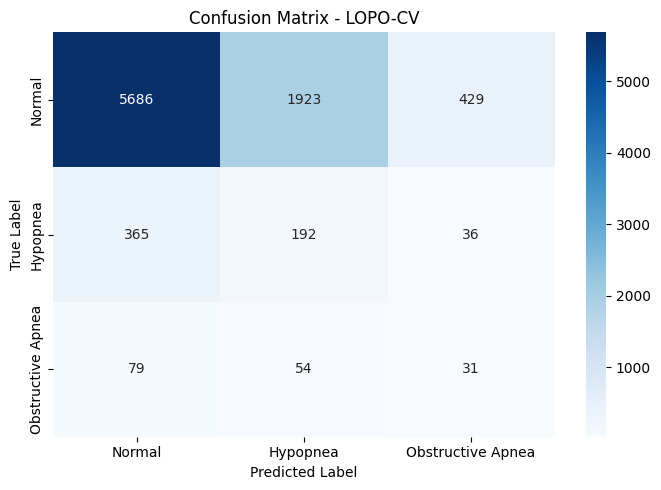

In [33]:
labels_name = ['Normal', 'Hypopnea', 'Obstructive Apnea']

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average='macro'))
print("Recall   :", recall_score(all_labels, all_preds, average='macro'))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_name, yticklabels=labels_name, cmap='Blues')
plt.title('Confusion Matrix - LOPO-CV')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Visualizations/confusion_matrix.png', dpi=150)
plt.show()